# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Muhammad Umar

**Roll Number:** 023-24-0260

**GitHub Repository:** https://github.com/muhammadumarofficial/Python-ML_Practices

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\umarc\Desktop\ML-Lab Practice\datasets\Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company wants to know why customers leave and target variable is Churn which shows whether a customer leaves or stays.

**Answer 2:**
Useful 
1. tenure: It shows how long the customer stays with the company.
2. Contract: The contract type may affect churn.
3. MonthlyCharges: High charges may make customers leave.
4. InternetService: Internet service may affect churn.
5. PaymentMethod: Payment method may affect churn.

Useless
1. customerID: It is only a customer ID.
2. SeniorCitizen: It may not directly affect churn.

**Answer 3:**
1. Why do customers leave the company?
2. Which type of customers leave the company more?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [4]:
#taks4

print("Rows and Columns:", df.shape)
print("Numerical columns:")
print(df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Rows and Columns: (7043, 21)
Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [5]:
#task5

print("identifier column:")
print("customerID")

print("\nWrong datatype:")
print(df.dtypes[df.dtypes == "object"])

identifier column:
customerID

Wrong datatype:
customerID          object
gender              object
Partner             object
Dependents          object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
TotalCharges        object
Churn               object
dtype: object


In [6]:
#task6
print("Gender:", df["gender"].unique())
print("Contract:", df["Contract"].unique())
print("InternetService:", df["InternetService"].unique())

Gender: ['Female' 'Male']
Contract: ['Month-to-month' 'One year' 'Two year']
InternetService: ['DSL' 'Fiber optic' 'No']


**Observations (Part 2):**
My observation :
   " The dataset has different types of columns and  CustomerID is only used to identify customers. There are numerical and categorical columns in the dataset and Churn is the target column. "

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [7]:
# Task 7 — missing values: count and percentage per column

print(df.isnull().sum())
print(df.isnull().mean() * 100)
print("missing TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64
missin

In [8]:
# Task 8 — duplicate rows vs duplicate IDs

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [9]:
# Task 9 — investigate a suspicious / invalid value
print(df["TotalCharges"].unique())

['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


**Answer 7 (which missing-value problems need action, and why):**
There are 11 blank values in TotalCharges. We need to handle them because missing values can affect our analysis.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
There are no duplicate rows and no duplicate customer IDs So, no action is needed because every row and customer ID is unique.

**Answer 9 (suspicious value found and how):**
TotalCharges has 11 blank values this is suspicious because TotalCharges should contain the total charges of each customer.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _Fill blank values with 0_ | _fillna(0)_ | _Blank means no total charge, so we avoid losing rows_ |
| _TotalCharges is stored as text_ | _Convert it to number_ | _pd.to_numeric()_ | _It contains charges, so it should be numeric_ |
| _No duplicate rows_ | _Keep the data_ | _No action_ | _there are no duplicate rows_ |

In [10]:
# Task 11 — apply your cleaning decisions here

clean_df = df.copy()
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset="customerID")

print(clean_df.shape)


(7043, 21)


In [11]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)

print("missing values:")
print(clean_df.isnull().sum())

print("duplicate rows:", clean_df.duplicated().sum())
print("duplicate customer IDs:", clean_df["customerID"].duplicated().sum())

print("totalCharges type:", clean_df["TotalCharges"].dtype)


missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
duplicate rows: 0
duplicate customer IDs: 0
totalCharges type: float64


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

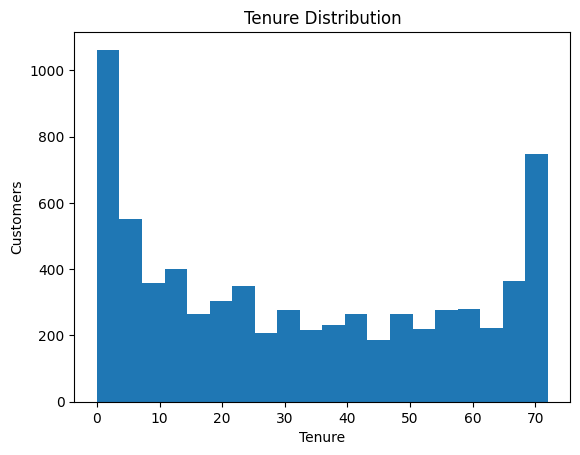

In [12]:
# Task 12 — numerical feature 1: distribution plot

clean_df["tenure"].plot(kind="hist", bins=20)
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Customers")
plt.show()


**Observation:** most customers have low tenure. Some customers have been with the company for a long time.

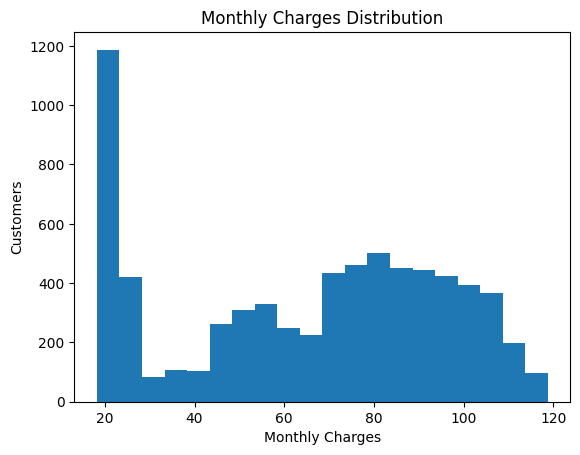

In [13]:
# Task 12 — numerical feature 2: distribution plot

clean_df["MonthlyCharges"].plot(kind="hist", bins=20)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")
plt.show()


**Observation:** monthly charges are spread across different values. Most customers have medium monthly charges.

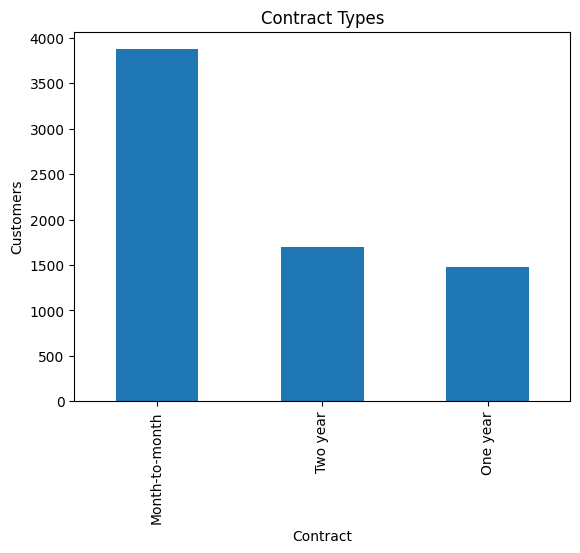

In [14]:
# Task 12 — categorical feature 1: distribution plot

clean_df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Types")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.show()


**Observation:** most customers have month-to-month contracts. Two-year contracts are less common.

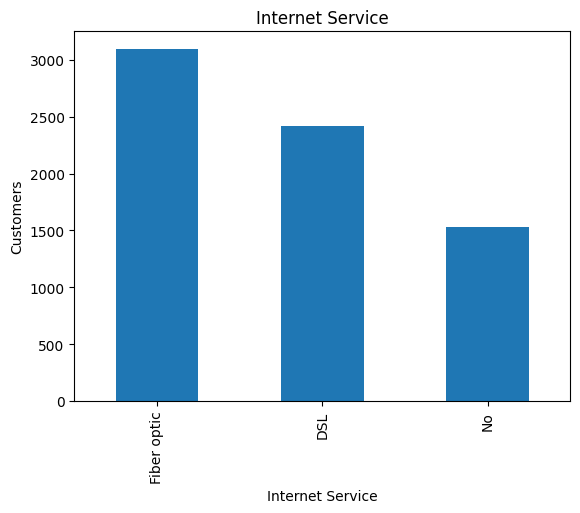

In [15]:
# Task 12 — categorical feature 2: distribution plot

clean_df["InternetService"].value_counts().plot(kind="bar")
plt.title("Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")
plt.show()

**Observation:** Fiber optic and DSL are the main internet services. Some customers do not use internet service.

**Answer 13 :**
Tenure has many customers with low values, so it is somewhat skewed. MonthlyCharges does not show any major outliers.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [25]:
# Task 14 — churn counts and percentages

print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
The target is imbalanced most customers did not churn, while fewer customers churned.

**Answer 15 (why imbalance might matter later):**
Class imbalance is important because the model may focus more on the larger class. It may not predict the smaller class well.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [34]:
# Task 16 — categorical feature 1 vs Churn

pd.crosstab(clean_df["Contract"], clean_df["Churn"], normalize="index") * 100



Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Observation:** Month-to-month customers churn more.
**Evidence:** Month-to-month customers have a higher churn percentage than one-year and two-year customers.
**Possible Explanation:** Short contracts may make it easier for customers to leave.

In [42]:
# Task 16 — categorical feature 2 vs Churn

pd.crosstab(clean_df["InternetService"], clean_df["Churn"], normalize="index") * 100


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**Observation:** Fiber optic customers churn more.
**Evidence:** Fiber optic has a higher churn percentage than DSL and no internet service.
**Possible Explanation:** Service cost or service problems may affect churn.

In [ ]:
# Task 17 — numerical feature 1 vs Churn

sns.boxplot(x="Churn", y="tenure", data=clean_df)
plt.title("Tenure vs Churn")
plt.show()


**Observation:** Customers who churn usually have lower tenure.
**Evidence:** The tenure of churned customers is generally lower than non-churned customers.
**Possible Explanation:** New customers may be more likely to leave.

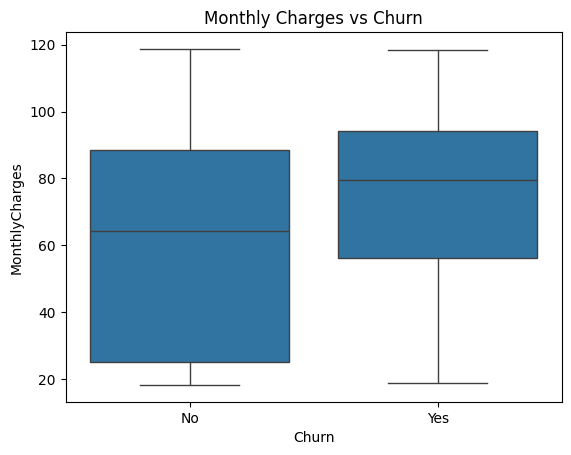

In [49]:
# Task 17 — numerical feature 2 vs Churn

sns.boxplot(x="Churn", y="MonthlyCharges", data=clean_df)
plt.title("Monthly Charges vs Churn")
plt.show()


**Observation:** Churned customers usually have higher monthly charges.
**Evidence:** The monthly charges of churned customers are generally higher.
**Possible Explanation:** High monthly charges may make customers leave.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


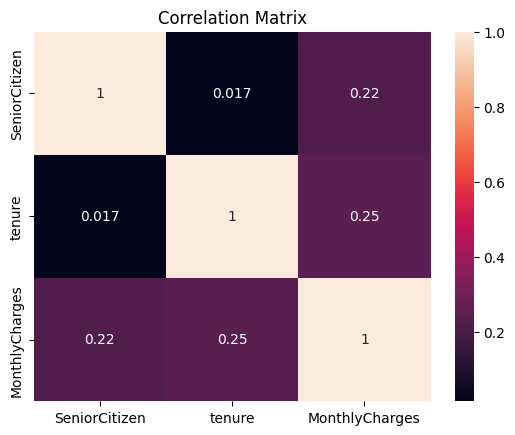

In [54]:
# Task 18 — correlation matrix and heatmap

corr_matrix = clean_df.corr(numeric_only=True)

print(corr_matrix)

sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()


**Answer 18 (most correlated pairs):**
The most correlated features are tenure and TotalCharges they have a strong positive relationship.

**Answer 19 (correlation vs. causation; potential problems):**
No, correlation does not mean causation. Highly correlated features can give similar information and may cause redundancy in a model.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID is a suspect column because it is only an ID and  Churn is also not a feature because it is the target we want to predict.

**Answer 21 (what would go wrong):**
If we use these columns as input, the model may learn wrong information. It can give very good results but may not work well on new customers.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | It is only an ID. |
| gender | Categorical | Feature | Keep | It gives customer information. |
| SeniorCitizen | Numerical | Feature | Keep | It gives customer information. |
| Partner | Categorical | Feature | Keep | It may affect churn. |
| Dependents | Categorical | Feature | Keep | It may affect churn. |
| tenure | Numerical | Feature | Keep | It shows how long the customer stays. |
| PhoneService | Categorical | Feature | Keep | It gives service information. |
| MultipleLines | Categorical | Feature | Keep | It gives service information. |
| InternetService | Categorical | Feature | Keep | It may affect churn. |
| OnlineSecurity | Categorical | Feature | Keep | It may affect churn. |
| OnlineBackup | Categorical | Feature | Keep | It may affect churn. |
| DeviceProtection | Categorical | Feature | Keep | It may affect churn. |
| TechSupport | Categorical | Feature | Keep | It may affect churn. |
| StreamingTV | Categorical | Feature | Keep | It gives service information. |
| StreamingMovies | Categorical | Feature | Keep | It gives service information. |
| Contract | Categorical | Feature | Keep | Contract type may affect churn. |
| PaperlessBilling | Categorical | Feature | Keep | It gives billing information. |
| PaymentMethod | Categorical | Feature | Keep | It may affect churn. |
| MonthlyCharges | Numerical | Feature | Keep | It shows the monthly bill. |
| TotalCharges | Numerical | Feature | Keep | It shows the total charges. |
| Churn | Categorical | Target | Keep | It is what we want to predict. |
_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [61]:
clean_df = df.copy()

clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset="customerID")

clean_df = clean_df.drop(columns=["customerID"])

clean_df.to_csv("clean_churn.csv", index=False)

In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df

print(clean_df.info())
print("Missing values:")
print(clean_df.isnull().sum())
print("Duplicate rows:", clean_df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Most customers do not churn.
- Evidence: About 73% customers stayed and 27% churned.
- Interpretation: Churn is lower than non-churn.

**Finding 2**
- Observation: Month-to-month customers churn more.
- Evidence: They have a higher churn rate than other contracts.
- Interpretation: Short contracts may make customers leave easily.

**Finding 3**
- Observation: New customers churn more.
- Evidence: Churned customers usually have lower tenure.
- Interpretation: New customers may be more likely to leave.

**Finding 4**
- Observation: Higher monthly charges are related to churn.
- Evidence: Churned customers usually have higher monthly charges.
- Interpretation: High charges may make customers leave._

**Finding 5**
- Observation: Fiber optic customers churn more.
- Evidence: Fiber optic has a higher churn rate than other internet services.
- Interpretation: Service cost or service problems may be a reason.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
  The most important issue was blank values in TotalCharges.
2. What was the most interesting pattern you discovered?
  Month-to-month customers were more likely to churn.
3. Which feature seems most useful for predicting churn?
  Contract seems most useful because contract type is related to churn.
4. Which feature should probably not be used, and why?
  CustomerID should not be used because it is only an ID.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
  We will need to handle missing values and convert categorical data into numbers._
6. What would you do next if you had another 3 hours?
 I would explore the data more and try a simple ML model.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook